#Código para otimização de memória de uma base de dados.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt


In [30]:
df = pd.read_csv("01_Netflix_2016_2025.csv", encoding="cp1252")

In [31]:
df.head()
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                200 non-null    int64  
 1   Title               200 non-null    str    
 2   IMDb                200 non-null    float64
 3   Viewership          200 non-null    str    
 4   Directors/Creators  200 non-null    str    
 5   Lead Actors         200 non-null    str    
 6   Release Date        200 non-null    str    
 7   Duration            200 non-null    str    
 8   Country             200 non-null    str    
 9   Genre               200 non-null    str    
dtypes: float64(1), int64(1), str(8)
memory usage: 98.4 KB


In [32]:
df["Country"].nunique()

25

In [33]:
paises = df["Country"].astype("category")

print(dict(enumerate(paises.cat.categories)))

df["Country"] = (df["Country"].astype("category").cat.codes.astype("int8"))



{0: 'Australia/USA', 1: 'Brazil', 2: 'Canada', 3: 'Canada/USA', 4: 'Colombia', 5: 'Denmark', 6: 'France', 7: 'Germany', 8: 'Japan', 9: 'Mexico', 10: 'Norway', 11: 'South Korea', 12: 'Spain', 13: 'Sweden', 14: 'UK', 15: 'UK/Canada', 16: 'UK/Italy', 17: 'UK/USA', 18: 'USA', 19: 'USA/Colombia', 20: 'USA/France', 21: 'USA/Japan', 22: 'USA/Mexico', 23: 'USA/Poland', 24: 'USA/UK'}


In [34]:
df["Release Date"] = pd.to_datetime(df["Release Date"], format="%d-%b-%y")

In [35]:
df["Genre"].nunique()

124

In [36]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Year                200 non-null    int64         
 1   Title               200 non-null    str           
 2   IMDb                200 non-null    float64       
 3   Viewership          200 non-null    str           
 4   Directors/Creators  200 non-null    str           
 5   Lead Actors         200 non-null    str           
 6   Release Date        200 non-null    datetime64[us]
 7   Duration            200 non-null    str           
 8   Country             200 non-null    int8          
 9   Genre               200 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), int8(1), str(6)
memory usage: 78.4 KB


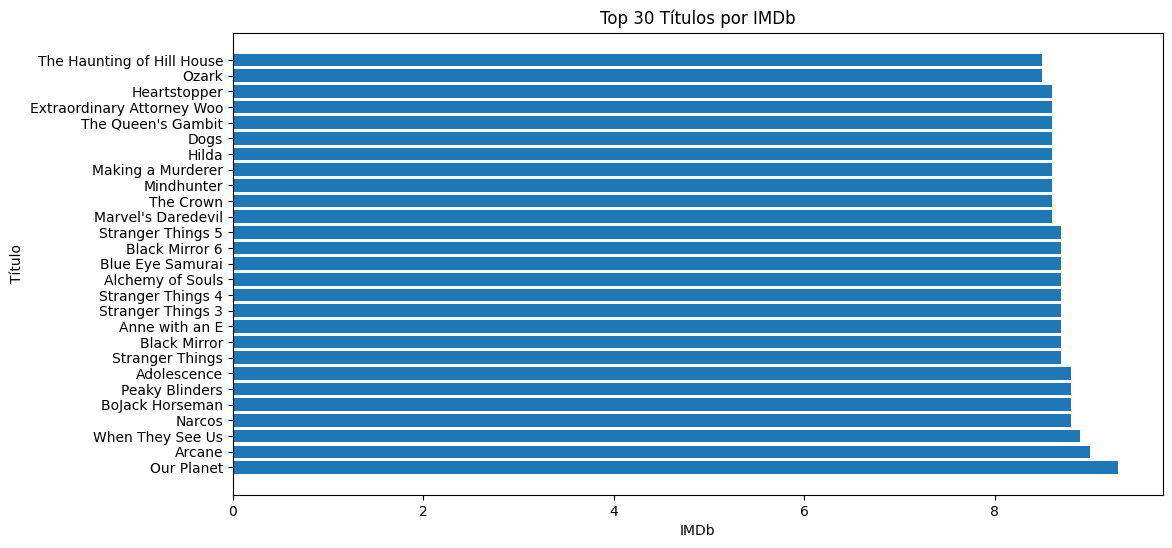

In [37]:
top10_imdb = df.nlargest(30, 'IMDb')

plt.figure(figsize=(12,6))
plt.barh(top10_imdb['Title'], top10_imdb['IMDb'])

plt.title('Top 30 Títulos por IMDb')
plt.xlabel('IMDb')
plt.ylabel('Título')

plt.show()

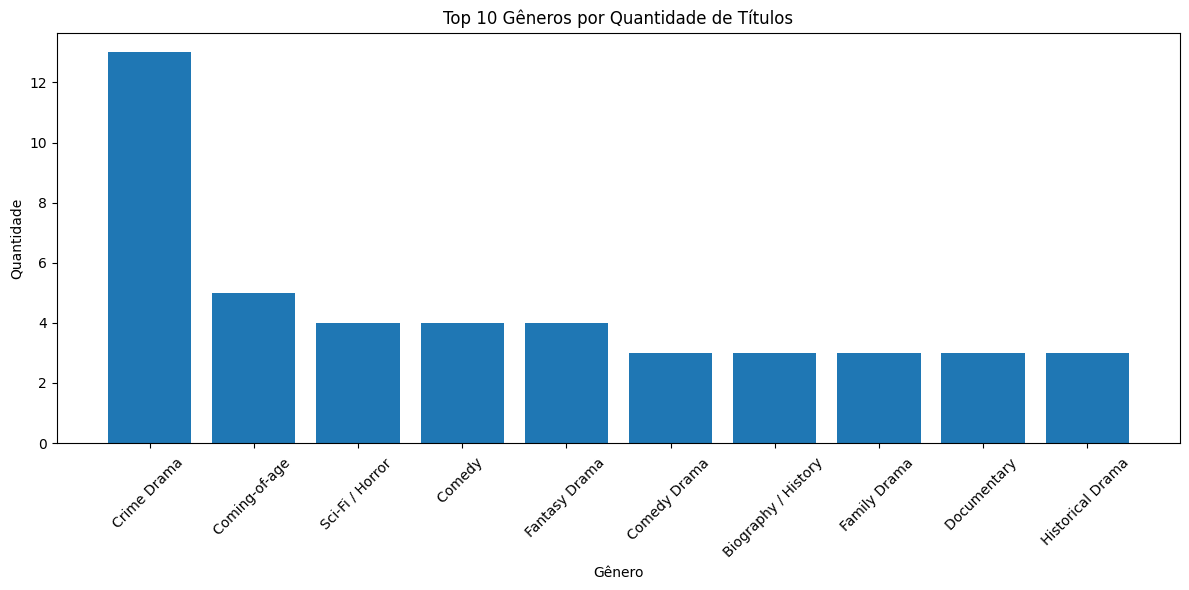

In [38]:
top_generos=df['Genre'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(top_generos.index, top_generos.values)

plt.title('Top 10 Gêneros por Quantidade de Títulos')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

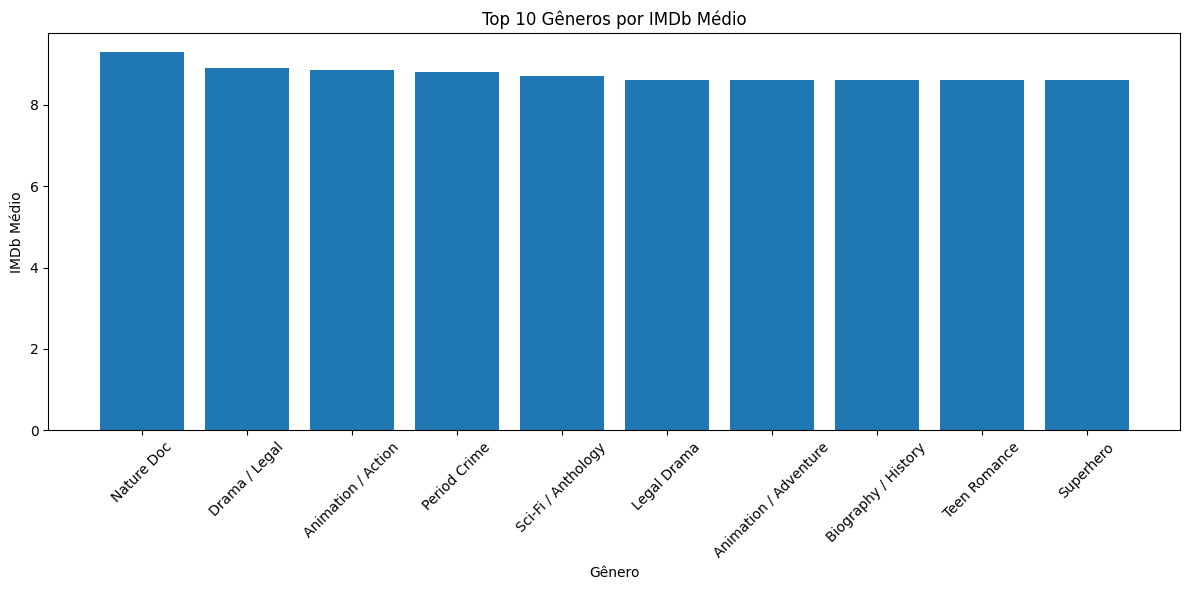

In [40]:
df_generos=df.copy()

df_generos['Genre']=df_generos['Genre'].str.split(',')

df_generos=df_generos.explode('Genre')

df_generos['Genre']=df_generos['Genre'].str.strip()

imdb_genero=(df_generos.groupby('Genre')['IMDb'].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))
plt.bar(imdb_genero.index, imdb_genero.values)

plt.title('Top 10 Gêneros por IMDb Médio')
plt.xlabel('Gênero')
plt.ylabel('IMDb Médio')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()